# STAR Part 3 — Gate Teleportation into a Logical Qubit

This notebook runs the noiseless STAR d=3 teleportation circuit.

**Protocol:**
1. Two STAR d=3 logical qubits — data patch (qubits 0–8) and ancilla patch (qubits 17–25)
2. Both initialized in |+>_L
3. Ancilla left column gets a transversal Rz(θ_phys) rotation
4. Transversal CNOT: data (control) → ancilla (target)
5. Ancilla data qubits measured in X basis

**Observables:**
- `obs[:,0]` — logical X of the data patch (`MPP X0*X1*X2`)
- `obs[:,1]` — logical X of the ancilla patch (XOR of first-row MX outcomes: q17, q18, q19)

**Post-selection:** keep shots where `obs[:,1] == 0` (Rz(+θ) teleported into data).

In [2]:
import numpy as np
import tsim
from pathlib import Path

In [3]:
# ── Physical angle helper ──────────────────────────────────────────────────────
# Maps a target logical rotation angle (in units of pi) to the physical angle
# needed for d physical qubits in the STAR code. Angle returned is in units of pi
# (matching tsim's R_Z convention where R_Z(a) applies Rz(a * pi) radians).

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int = 3) -> float:
    """Return physical rotation angle (in units of pi) for STAR d=3 injection."""
    assert num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    t = np.tan(logical_angle_in_pi * np.pi / 2)
    x = np.sign(t) * (np.abs(t) ** (1 / num_physical_rotations))
    return float(sign * 2 * np.arctan(x) / np.pi)


# Verify: logical 0.01*pi should give the angle stored in the stim file
phys = physical_angle(0.01)
print(f"physical_angle(0.01*pi, d=3) = {phys:.16f}")
print(f"matches stim file: {np.isclose(phys, -0.1562269946295373)}")

physical_angle(0.01*pi, d=3) = -0.1562269946295373
matches stim file: True


## 1. Load and inspect the circuit

In [6]:
STIM_PATH = Path("../assets/star_circuits/star_d=3 teleportation.stim")

circuit = tsim.Circuit.from_file(str(STIM_PATH))

print(f"Qubits:        {circuit.num_qubits}")
print(f"Measurements:  {circuit.num_measurements}")
print(f"Observables:   {circuit.num_observables}")
print(f"Detectors:     {circuit.num_detectors}")
print(f"Is Clifford:   {circuit.is_clifford}")

Qubits:        26
Measurements:  10
Observables:   2
Detectors:     0
Is Clifford:   False


## 2. Run a single angle

In [7]:
N_SHOTS = 100_000

sampler = circuit.compile_detector_sampler()
# separate_observables=True returns (detectors, observables) as separate arrays
# detectors shape: (N_SHOTS, 0)  — no DETECTOR instructions in this circuit
# observables shape: (N_SHOTS, 2)  — obs[:,0]=data logical X, obs[:,1]=ancilla logical X
_, obs = sampler.sample(N_SHOTS, separate_observables=True)

print(f"obs shape: {obs.shape}")
print(f"obs[:,0] (data logical X)    mean: {obs[:,0].mean():.5f}")
print(f"obs[:,1] (ancilla logical X) mean: {obs[:,1].mean():.5f}")

obs shape: (100000, 2)
obs[:,0] (data logical X)    mean: 0.05938
obs[:,1] (ancilla logical X) mean: 0.05938


In [8]:
# Post-select: keep shots where ancilla logical X == 0
# obs[:,1]==0  ->  Rz(+theta) was teleported into data
# obs[:,1]==1  ->  Rz(-theta) was applied (discard)

keep = obs[:, 1] == 0
n_kept = keep.sum()
survival_rate = n_kept / N_SHOTS

data_logical_x_err = obs[keep, 0].mean()

theta = 0.01  # logical rotation angle in units of pi (default in stim file)
expected_err = np.sin(theta * np.pi / 2) ** 2

print(f"Survival rate:      {survival_rate:.2%}  ({n_kept}/{N_SHOTS} shots kept)")
print(f"Data logical X err: {data_logical_x_err:.6f}")
print(f"Expected err:       {expected_err:.6e}  (sin²({theta}π/2))")

Survival rate:      94.06%  (94062/100000 shots kept)
Data logical X err: 0.000000
Expected err:       2.467198e-04  (sin²(0.01π/2))


## 3. Build circuit programmatically for arbitrary angle

Instead of loading from file, build the circuit string directly so we can sweep over angles.

In [9]:
STIM_TEMPLATE = """
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(1.5, 0.5) 1
QUBIT_COORDS(2.5, 0.5) 2
QUBIT_COORDS(0.5, 1.5) 3
QUBIT_COORDS(1.5, 1.5) 4
QUBIT_COORDS(2.5, 1.5) 5
QUBIT_COORDS(0.5, 2.5) 6
QUBIT_COORDS(1.5, 2.5) 7
QUBIT_COORDS(2.5, 2.5) 8
QUBIT_COORDS(4.5, 0.5) 17
QUBIT_COORDS(5.5, 0.5) 18
QUBIT_COORDS(6.5, 0.5) 19
QUBIT_COORDS(4.5, 1.5) 20
QUBIT_COORDS(5.5, 1.5) 21
QUBIT_COORDS(6.5, 1.5) 22
QUBIT_COORDS(4.5, 2.5) 23
QUBIT_COORDS(5.5, 2.5) 24
QUBIT_COORDS(6.5, 2.5) 25
RX 0 1 2 3 4 5 6 7 8
RX 17 18 19 20 21 22 23 24 25
TICK
R_Z({phys_angle:.16f}) 17 20 23
TICK
CX 0 17 1 18 2 19 3 20 4 21 5 22 6 23 7 24 8 25
TICK
MX 17 18 19 20 21 22 23 24 25
TICK
OBSERVABLE_INCLUDE(1) rec[-9] rec[-8] rec[-7]
MPP X0*X1*X2
OBSERVABLE_INCLUDE(0) rec[-1]
"""


def build_circuit(logical_angle_pi: float) -> tsim.Circuit:
    phys = physical_angle(logical_angle_pi)
    return tsim.Circuit(STIM_TEMPLATE.format(phys_angle=phys))


def run_teleportation(logical_angle_pi: float, n_shots: int = 50_000):
    """Run teleportation circuit and return post-selected error rate."""
    circ = build_circuit(logical_angle_pi)
    sampler = circ.compile_detector_sampler()
    _, obs = sampler.sample(n_shots, separate_observables=True)

    # obs[:,0]: data logical X
    # obs[:,1]: ancilla logical X  (0 = success, 1 = discard)
    keep = obs[:, 1] == 0
    survival = keep.mean()
    err = obs[keep, 0].mean() if keep.any() else float("nan")
    expected = np.sin(logical_angle_pi * np.pi / 2) ** 2
    return survival, err, expected


# Quick test
survival, err, expected = run_teleportation(0.01)
print(f"theta=0.01pi: survival={survival:.2%}, err={err:.6f}, expected={expected:.6e}")

theta=0.01pi: survival=94.06%, err=0.000000, expected=2.467198e-04


## 4. Sweep over rotation angles

In [10]:
angles = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
N = 50_000

results = []
print(f"{'theta (pi)':<12} {'survival':>10} {'meas err':>12} {'expected':>12}")
print("-" * 50)
for theta in angles:
    survival, err, expected = run_teleportation(theta, n_shots=N)
    results.append((theta, survival, err, expected))
    print(f"{theta:<12.4f} {survival:>10.2%} {err:>12.6f} {expected:>12.6f}")

theta (pi)     survival     meas err     expected
--------------------------------------------------
0.0010           98.66%     0.000000     0.000002
0.0100           93.96%     0.000000     0.000247
0.0500           84.23%     0.000000     0.006156
0.1000           77.16%     0.000000     0.024472
0.2000           68.07%     0.000000     0.095492
0.3000           61.12%     0.000000     0.206107
0.4000           54.78%     0.000000     0.345492
0.5000           50.06%     0.000000     0.500000


(np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0))


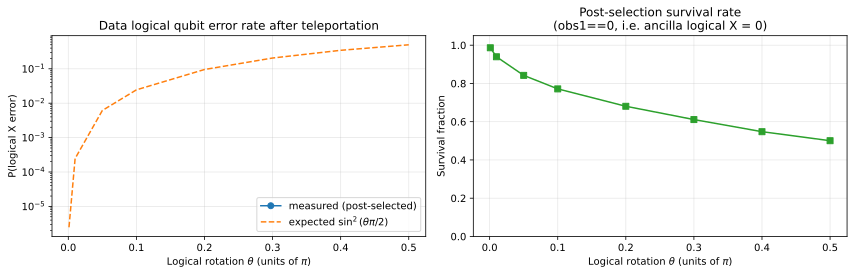

Saved teleportation_results.png


In [13]:
import matplotlib.pyplot as plt

thetas, survivals, errs, expecteds = zip(*results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
print(errs)
# Left: error rate vs expected
ax = axes[0]
ax.plot(thetas, errs, 'o-', label='measured (post-selected)', color='C0')
ax.plot(thetas, expecteds, '--', label=r'expected $\sin^2(\theta\pi/2)$', color='C1')
ax.set_xlabel(r'Logical rotation $\theta$ (units of $\pi$)')
ax.set_ylabel('P(logical X error)')
ax.set_title('Data logical qubit error rate after teleportation')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Right: survival rate (fraction of post-selected shots)
ax = axes[1]
ax.plot(thetas, survivals, 's-', color='C2')
ax.set_xlabel(r'Logical rotation $\theta$ (units of $\pi$)')
ax.set_ylabel('Survival fraction')
ax.set_title('Post-selection survival rate\n(obs1==0, i.e. ancilla logical X = 0)')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('teleportation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved teleportation_results.png")

## 5. Inspect raw measurement outcomes

Use `compile_sampler()` to inspect the individual MX outcomes (not just the logical observables).

In [12]:
# Raw measurement sampler: returns all measurement bits
# Measurement order:
#   [0]...[8]  : MX 17,18,19,20,21,22,23,24,25  (ancilla data qubits in X basis)
#   [9]        : MPP X0*X1*X2                    (data logical X)

circ = build_circuit(0.3)  # use a large angle so we see more variation
raw_sampler = circ.compile_sampler()
samples = raw_sampler.sample(10)

ancilla_labels = [f"q{q}" for q in [17,18,19,20,21,22,23,24,25]]
col_labels = ancilla_labels + ["data_logX"]
print("  " + "  ".join(f"{l:>7}" for l in col_labels))
for i, row in enumerate(samples):
    vals = [int(b) for b in row]
    print(f"{i} " + "  ".join(f"{v:>7}" for v in vals))
    
print()
print("Observable 1 (ancilla logical X = XOR of q17,q18,q19):")
for row in samples:
    vals = [int(b) for b in row]
    anc_logx = vals[0] ^ vals[1] ^ vals[2]  # first row: q17, q18, q19
    data_logx = vals[9]
    print(f"  anc_logX={anc_logx}  data_logX={data_logx}")

      q17      q18      q19      q20      q21      q22      q23      q24      q25  data_logX
0       0        0        0        0        0        0        1        0        0        0
1       1        0        0        1        0        0        1        0        0        1
2       0        0        0        1        0        0        0        0        0        0
3       0        0        0        0        0        0        1        0        0        0
4       1        0        0        0        0        0        1        0        0        1
5       1        0        0        0        0        0        1        0        0        1
6       1        0        0        0        0        0        1        0        0        1
7       0        0        0        0        0        0        0        0        0        0
8       0        0        0        0        0        0        1        0        0        0
9       0        0        0        0        0        0        0        0        0       